In [ ]:
from pathlib import Path

# === RUN THIS FIRST: repo-root anchor so paths resolve from any working dir ===
# Walks up until it finds the repo root (the folder containing both ai/ and src/).
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "ai").is_dir() and (p / "src").is_dir()), Path.cwd())

DATASETS = ROOT / "ai" / "data" / "datasets"                      # datasets root
RUNS     = ROOT / "ai" / "runs"                                   # training/eval output
DEPLOY   = ROOT / "ai" / "models" / "subsystem1" / "production"   # deployed .pt models

print("ROOT     =", ROOT)
print("DATASETS =", DATASETS)
print("RUNS     =", RUNS)
print("DEPLOY   =", DEPLOY)

In [15]:
import os
import glob
import yaml
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def analyze_yolo_dataset_counts(dataset_dir):
    """
    Analyzes a YOLOv8 format dataset folder specifically focusing on 
    the total numbers and percentages of images and bounding boxes per split.
    """
    yaml_path = os.path.join(dataset_dir, "data.yaml")

    if not os.path.exists(yaml_path):
        raise FileNotFoundError(f"Could not find data.yaml at {yaml_path}. Check your path!")

    with open(yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)

    class_names = data_config.get('names', [])
    print(f"Found Dataset Classes: {class_names}\n")

    def analyze_split(split_name):
        img_dir = os.path.join(dataset_dir, split_name, "images")
        lbl_dir = os.path.join(dataset_dir, split_name, "labels")
        
        if not os.path.exists(img_dir):
            return []
            
        img_files = glob.glob(os.path.join(img_dir, "*.*"))
        records = []
        
        for img_path in tqdm(img_files, desc=f"Analyzing {split_name}"):
            base_name = os.path.splitext(os.path.basename(img_path))[0]
            lbl_path = os.path.join(lbl_dir, f"{base_name}.txt")
            
            box_count = 0
            if os.path.exists(lbl_path):
                with open(lbl_path, 'r') as f:
                    lines = f.readlines()
                    for line in lines:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            records.append({
                                "Split": split_name,
                                "Image": base_name,
                                "Is_Object": 1
                            })
                            box_count += 1
                            
            if box_count == 0:
                records.append({
                    "Split": split_name,
                    "Image": base_name,
                    "Is_Object": 0
                })
                
        return records

    # Gather data from standard splits
    all_data = []
    for split in ["train", "val", "test"]:
        all_data.extend(analyze_split(split))

    if not all_data:
        print("No data found to analyze.")
        return

    df = pd.DataFrame(all_data)
    unique_imgs = df.drop_duplicates(subset=["Split", "Image"])

    total_images_all = len(unique_imgs)
    total_boxes_all = len(df[df["Is_Object"] == 1])

    print("\n==========================================================")
    print("DATASET METRICS & PERCENTAGE DISTRIBUTION")
    print("==========================================================")
    
    splits_found = ["train", "val", "test"]
    summary_data = []
    
    for split in splits_found:
        split_imgs = unique_imgs[unique_imgs["Split"] == split]
        split_boxes = df[(df["Split"] == split) & (df["Is_Object"] == 1)]
        
        img_count = len(split_imgs)
        box_count = len(split_boxes)
        
        img_pct = (img_count / total_images_all) * 100 if total_images_all > 0 else 0
        box_pct = (box_count / total_boxes_all) * 100 if total_boxes_all > 0 else 0
        
        summary_data.append({
            "Split": split,
            "Images Count": img_count,
            "Images %": f"{img_pct:.1f}%",
            "Bounding Boxes": box_count,
            "Boxes %": f"{box_pct:.1f}%"
        })
        
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_markdown(index=False))
    print(f"\nTotal Dataset Images: {total_images_all}")
    print(f"Total Dataset Bounding Boxes: {total_boxes_all}")
    print("==========================================================\n")

    # --- PLOT SIMPLIFIED DISTRIBUTION ---
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Graph 1: Image Split Breakdown
    img_counts_series = unique_imgs["Split"].value_counts().reindex(splits_found, fill_value=0)
    if img_counts_series.sum() > 0:
        axes[0].pie(img_counts_series, labels=img_counts_series.index, autopct='%1.1f%%', 
                    startangle=140, colors=sns.color_palette("Set2", len(img_counts_series)))
        axes[0].set_title("Image Distribution Split (%)")
    else:
        axes[0].text(0.5, 0.5, "No images found", ha='center')

    # Graph 2: Total Bounding Box counts per split
    instances_df = df[df["Is_Object"] == 1]
    if not instances_df.empty:
        sns.countplot(data=instances_df, x="Split", hue="Split", order=splits_found, ax=axes[1], palette="muted", legend=False)
        axes[1].set_title("Total Bounding Boxes per Split")
        axes[1].set_ylabel("Count")
        axes[1].set_xlabel("Split")
    else:
        axes[1].text(0.5, 0.5, "No bounding boxes found", ha='center')

    plt.tight_layout()
    plt.show()

Found Dataset Classes: ['tin']



Analyzing train:   0%|          | 0/211 [00:00<?, ?it/s]

Analyzing test: 100%|██████████| 45/45 [00:00<00:00, 136.79it/s]



DATASET METRICS & PERCENTAGE DISTRIBUTION
| Split   |   Images Count | Images %   |   Bounding Boxes | Boxes %   |
|:--------|---------------:|:-----------|-----------------:|:----------|
| train   |            211 | 82.4%      |              251 | 81.5%     |
| val     |              0 | 0.0%       |                0 | 0.0%      |
| test    |             45 | 17.6%      |               57 | 18.5%     |

Total Dataset Images: 256
Total Dataset Bounding Boxes: 308



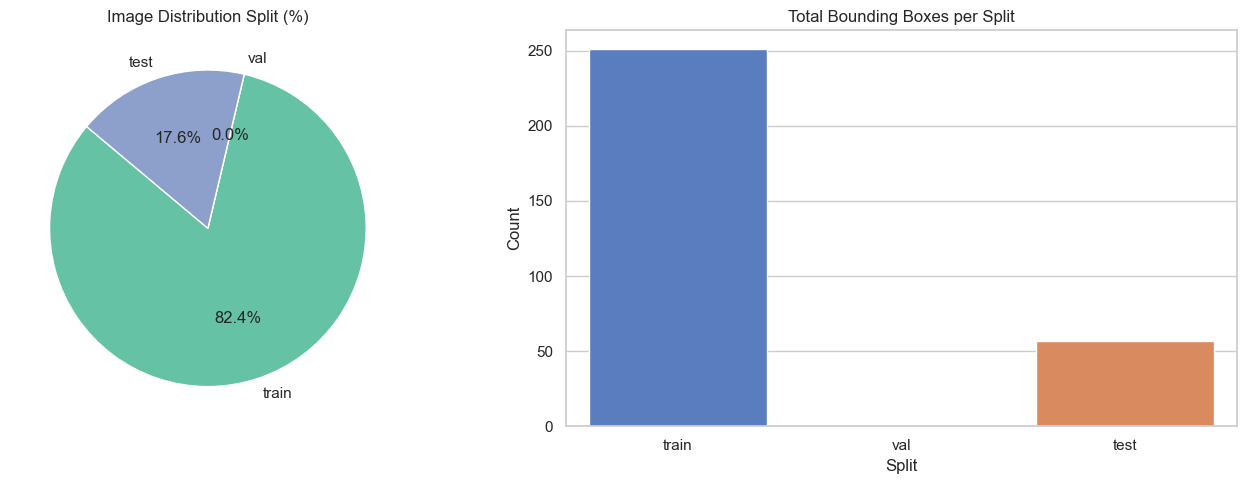

In [16]:
analyze_yolo_dataset_counts(str(DATASETS / "tin.yolov8.1"))

Found Dataset Classes: ['tin']



Analyzing test: 100%|██████████| 144/144 [00:01<00:00, 129.89it/s]



DATASET METRICS & PERCENTAGE DISTRIBUTION
| Split   |   Images Count | Images %   |   Bounding Boxes | Boxes %   |
|:--------|---------------:|:-----------|-----------------:|:----------|
| train   |            730 | 83.5%      |              865 | 83.7%     |
| val     |              0 | 0.0%       |                0 | 0.0%      |
| test    |            144 | 16.5%      |              168 | 16.3%     |

Total Dataset Images: 874
Total Dataset Bounding Boxes: 1033



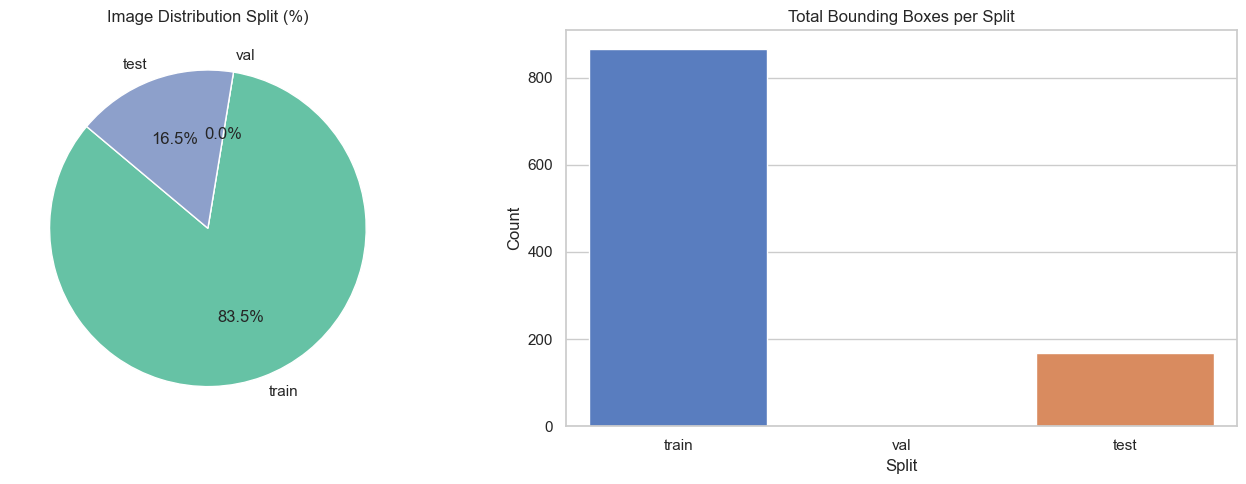

In [17]:
analyze_yolo_dataset_counts(str(DATASETS / "tin.yolov8.2"))

In [18]:
import os
import shutil
import glob
import yaml

def merge_datasets_direct(dir1, dir2, output_dir):
    print("Starting direct dataset merge...")
    
    # We only process the splits that actually exist based on your logs
    splits = ['train', 'test']
    for split in splits:
        os.makedirs(os.path.join(output_dir, split, 'images'), exist_ok=True)
        os.makedirs(os.path.join(output_dir, split, 'labels'), exist_ok=True)

    def copy_split_data(src_dataset_dir, prefix):
        for split in splits:
            img_dir = os.path.join(src_dataset_dir, split, 'images')
            lbl_dir = os.path.join(src_dataset_dir, split, 'labels')
            
            if not os.path.exists(img_dir):
                continue
                
            img_files = glob.glob(os.path.join(img_dir, "*.*"))
            for img_path in img_files:
                base_name = os.path.splitext(os.path.basename(img_path))[0]
                ext = os.path.splitext(img_path)[1]
                lbl_path = os.path.join(lbl_dir, f"{base_name}.txt")
                
                # Unique name mapping to avoid filename collisions
                new_name = f"{prefix}_{base_name}"
                
                dest_img = os.path.join(output_dir, split, 'images', f"{new_name}{ext}")
                dest_lbl = os.path.join(output_dir, split, 'labels', f"{new_name}.txt")
                
                # Copy Image File
                shutil.copy2(img_path, dest_img)
                
                # Copy Label File if it exists, otherwise create empty file for background images
                if os.path.exists(lbl_path):
                    shutil.copy2(lbl_path, dest_lbl)
                else:
                    open(dest_lbl, 'w').close()

    # Copy files directly from both source directories
    copy_split_data(dir1, prefix="ds1")
    copy_split_data(dir2, prefix="ds2")

    # Generate the updated data.yaml file mapping directly to train and test
    yaml_content = {
        'path': os.path.abspath(output_dir),
        'train': 'train/images',
        'test': 'test/images',
        'names': {0: 'tin'}
    }
    
    with open(os.path.join(output_dir, 'data.yaml'), 'w') as f:
        yaml.safe_dump(yaml_content, f, default_flow_style=False)
        
    print(f"\nSuccess! Directly merged dataset created at: {output_dir}")

# --- EXECUTE DIRECT MERGE ---
merge_datasets_direct(
    dir1=str(DATASETS / "tin.yolov8.1"),
    dir2=str(DATASETS / "tin.yolov8.2"),
    output_dir=str(DATASETS / "tin.yolov8")
)

Starting direct dataset merge...

Success! Directly merged dataset created at: ../data/tin.yolov8


Dataset Classes: {0: 'tin'}



Processing train:   0%|          | 0/3370 [00:00<?, ?it/s]

Processing test: 100%|██████████| 321/321 [00:24<00:00, 13.27it/s]



DATASET METRICS & PERCENTAGE DISTRIBUTION
| Split   |   Images Count | Images %   |   Bounding Boxes | Boxes %   |
|:--------|---------------:|:-----------|-----------------:|:----------|
| train   |           3370 | 84.3%      |             3716 | 83.2%     |
| val     |            307 | 7.7%       |              377 | 8.4%      |
| test    |            321 | 8.0%       |              375 | 8.4%      |

Total Dataset Images: 3998
Total Dataset Bounding Boxes: 4468



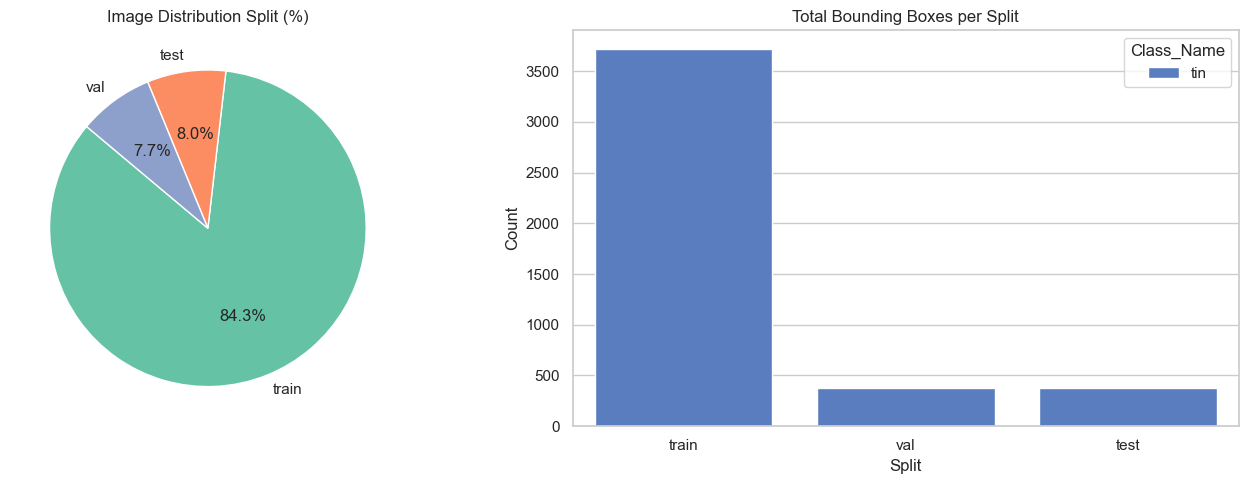

In [22]:
import os
import glob
import yaml
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def analyze_combined_dataset(dataset_dir):
    yaml_path = os.path.join(dataset_dir, "data.yaml")

    if not os.path.exists(yaml_path):
        raise FileNotFoundError(f"Could not find data.yaml at {yaml_path}.")

    with open(yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)

    class_names = data_config.get('names', [])
    print(f"Dataset Classes: {class_names}\n")

    def analyze_split(split_name):
        img_dir = os.path.join(dataset_dir, split_name, "images")
        lbl_dir = os.path.join(dataset_dir, split_name, "labels")
        
        if not os.path.exists(img_dir):
            return []
            
        img_files = glob.glob(os.path.join(img_dir, "*.*"))
        records = []
        
        for img_path in tqdm(img_files, desc=f"Processing {split_name}"):
            base_name = os.path.splitext(os.path.basename(img_path))[0]
            lbl_path = os.path.join(lbl_dir, f"{base_name}.txt")
            
            img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
            height, width = img.shape[:2] if img is not None else (0, 0)
            
            box_count = 0
            if os.path.exists(lbl_path):
                with open(lbl_path, 'r') as f:
                    lines = f.readlines()
                    for line in lines:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            class_id = int(parts[0])
                            class_name = class_names[class_id] if class_id < len(class_names) else f"Unknown_{class_id}"
                            
                            records.append({
                                "Split": split_name,
                                "Image": base_name,
                                "Width": width,
                                "Height": height,
                                "Class_Name": class_name,
                                "Is_Object": 1
                            })
                            box_count += 1
                            
            if box_count == 0:
                records.append({
                    "Split": split_name,
                    "Image": base_name,
                    "Width": width,
                    "Height": height,
                    "Class_Name": "Background/Empty",
                    "Is_Object": 0
                })
                
        return records

    # Scan all possible standard splits
    all_data = []
    for split in ["train", "val", "test"]:
        all_data.extend(analyze_split(split))

    df = pd.DataFrame(all_data)
    unique_imgs = df.drop_duplicates(subset=["Split", "Image"])

    # --- CALCULATE COUNTS AND PERCENTAGES ---
    total_images_all = len(unique_imgs)
    total_boxes_all = len(df[df["Is_Object"] == 1])

    print("\n==========================================================")
    print("DATASET METRICS & PERCENTAGE DISTRIBUTION")
    print("==========================================================")
    
    splits_found = unique_imgs["Split"].unique()
    
    summary_data = []
    for split in splits_found:
        split_imgs = unique_imgs[unique_imgs["Split"] == split]
        split_boxes = df[(df["Split"] == split) & (df["Is_Object"] == 1)]
        
        img_count = len(split_imgs)
        box_count = len(split_boxes)
        
        img_pct = (img_count / total_images_all) * 100
        box_pct = (box_count / total_boxes_all) * 100 if total_boxes_all > 0 else 0
        
        summary_data.append({
            "Split": split,
            "Images Count": img_count,
            "Images %": f"{img_pct:.1f}%",
            "Bounding Boxes": box_count,
            "Boxes %": f"{box_pct:.1f}%"
        })
        
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_markdown(index=False))
    print(f"\nTotal Dataset Images: {total_images_all}")
    print(f"Total Dataset Bounding Boxes: {total_boxes_all}")
    print("==========================================================\n")

    # --- PLOT DISTRIBUTION ---
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Graph 1: Image Distribution Percentage Pie Chart
    img_counts_series = unique_imgs["Split"].value_counts()
    axes[0].pie(img_counts_series, labels=img_counts_series.index, autopct='%1.1f%%', 
                startangle=140, colors=sns.color_palette("Set2", len(img_counts_series)))
    axes[0].set_title("Image Distribution Split (%)")

    # Graph 2: Object Bounding Box counts
    instances_df = df[df["Is_Object"] == 1]
    if not instances_df.empty:
        sns.countplot(data=instances_df, x="Split", hue="Class_Name", ax=axes[1], palette="muted")
        axes[1].set_title("Total Bounding Boxes per Split")
        axes[1].set_ylabel("Count")
    else:
        axes[1].text(0.5, 0.5, "No bounding boxes found", ha='center')

    plt.tight_layout()
    plt.show()

analyze_combined_dataset(str(DATASETS / "tin.yolov8.split"))